In [2]:
from scipy.special import ellipk, ellipe
import math

In [13]:
def A_phi(r, z):
    mu_0 = 4*math.pi*1e-7
    a = 0.1
    I = 1.0

    k = math.sqrt(4*a*r/((a+r)**2+z**2))
    return mu_0 * I / (math.pi * k) * math.sqrt(a/r) * ((1-k**2/2)*ellipk(k)-ellipe(k))

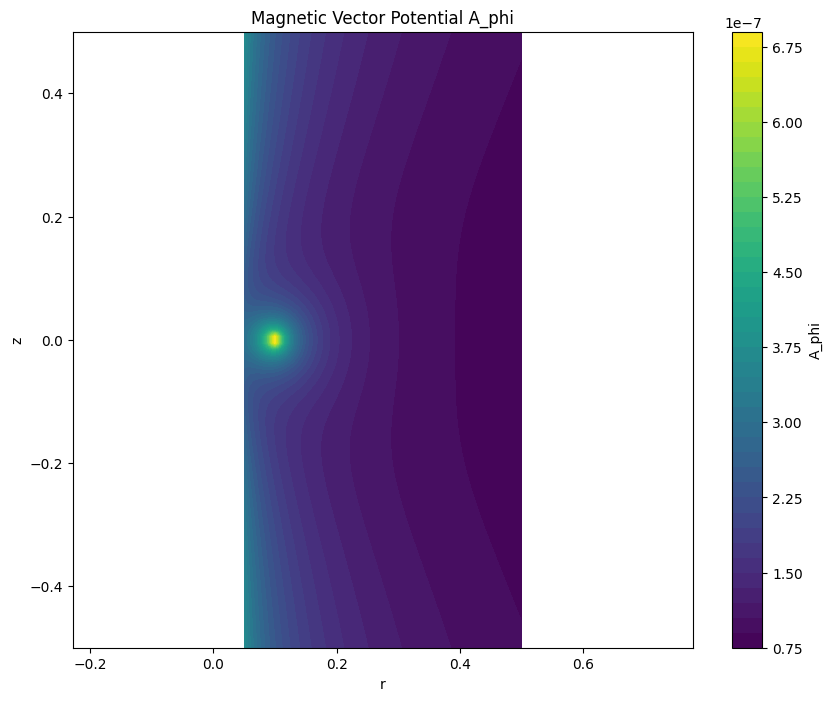

In [14]:
import numpy as np
import matplotlib.pyplot as plt

# Define the grid
r = np.linspace(0.05, 0.5, 100) # Start from 0.001 to avoid division by zero at r=0
z = np.linspace(-0.5, 0.5, 100)
R, Z = np.meshgrid(r, z)

# Vectorize the A_phi function to work with numpy arrays
A_phi_vec = np.vectorize(A_phi)

# Calculate A_phi over the grid
A = A_phi_vec(R, Z)

# Plot the results
plt.figure(figsize=(10, 8))
cp = plt.contourf(R, Z, A, levels=50, cmap='viridis')
plt.colorbar(cp, label='A_phi')
plt.title('Magnetic Vector Potential A_phi')
plt.xlabel('r')
plt.ylabel('z')
plt.axis('equal')
plt.show()

In [15]:
print(A_phi(0.0999, 0))

1.4673884103056178e-06
